Notebook on using `cosmotools` to extract parameter constraints using `getdist`, getting $\chi^2$, getting $\ln\mathcal{Z}$ estimates using `MCEvidence` and `harmonic`



In [1]:
from cosmctools import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def make_and_train(root, params, burnin, block_num, temp=0.8):
    m = cosmo_model(root, burnin=burnin, block_num=block_num)
    m.set_sampled_params(params)
    m.train_model(verbose=False)
    m.set_temp(temp=temp)
    return m


def to_lnZ(hm_res):
    """harmonic returns (-lnZ, (err_low_inv, err_up_inv)); convert to (lnZ, err_low, err_up)."""
    inv, err_inv = hm_res
    return -inv, abs(err_inv[1]), abs(err_inv[0])

# Comparing the effects of parameter choices on evidences

looking at the sampled parameters in MCMC samples, can catagorise into:

1) constrained cosmological parameters

2) unconstrained cosmological parameters (prior dominated)

3) nuisance parameters (can be also prior dominated)

## Plan

- get evidence for the following set of parameters:

    - all sampled parameters

    - excluding nuisance parameters (cosmological parameters only)

    - excluding the prior dominated parameters (keep constrained cosmological parameters and nuisance parameters)

    - only constrained cosmological parameters

- check both Bayesian evidence and Bayes factor to see if there are variations

- 

In [3]:
# including or excluding nuisance parameters (CMB+BAO+SNe)

## parameters
lcdm_cosmo_params = [
    "theta_s_100",
    "omega_b",
    "omega_cdm",
    "logA",
    "n_s",
    "tau_reio;0.9999995",
]
nuisance_params = ["A_planck", "P_act", "Tcal;0.9999995", "Ecal"]
cpl_cosmo_params = lcdm_cosmo_params + ["w0_fld", "wa_fld"]

## initialising objects
lcdm_cosmo_only = cosmo_model("../lcdm_chains/ts_CMB-SPA+DD+DESI", block_num=12)
lcdm_full = cosmo_model("../lcdm_chains/ts_CMB-SPA+DD+DESI", block_num=12)
cpl_cosmo_only = cosmo_model(
    "../cpl_chains/ts_CMB-SPA+DD+DESI", block_num=12, burnin=0.5
)
cpl_full = cosmo_model("../cpl_chains/ts_CMB-SPA+DD+DESI", block_num=12, burnin=0.5)

## setting parameters
lcdm_cosmo_only.set_sampled_params(lcdm_cosmo_params)
lcdm_full.set_sampled_params(lcdm_cosmo_params + nuisance_params)
cpl_cosmo_only.set_sampled_params(cpl_cosmo_params)
cpl_full.set_sampled_params(cpl_cosmo_params + nuisance_params)

## check convergence on chains such so that correct burnin has been removed
print(f"LCDM R-1 = {lcdm_cosmo_only.get_gelman_rubin()}")
print(f"CPL R-1 = {cpl_cosmo_only.get_gelman_rubin()}")

../lcdm_chains/ts_CMB-SPA+DD+DESI.1.txt
../lcdm_chains/ts_CMB-SPA+DD+DESI.2.txt
../lcdm_chains/ts_CMB-SPA+DD+DESI.3.txt
../lcdm_chains/ts_CMB-SPA+DD+DESI.4.txt
Removed 0.3 as burn in
LCDM R-1 = 0.00819280250382877
../cpl_chains/ts_CMB-SPA+DD+DESI.1.txt
../cpl_chains/ts_CMB-SPA+DD+DESI.2.txt
../cpl_chains/ts_CMB-SPA+DD+DESI.3.txt
../cpl_chains/ts_CMB-SPA+DD+DESI.4.txt
Removed 0.5 as burn in
CPL R-1 = 0.009385908497231667


W0407 03:18:42.329722 8200784 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
Training NF: 100%|██████████| 15/15 [00:28<00:00,  1.90s/it]


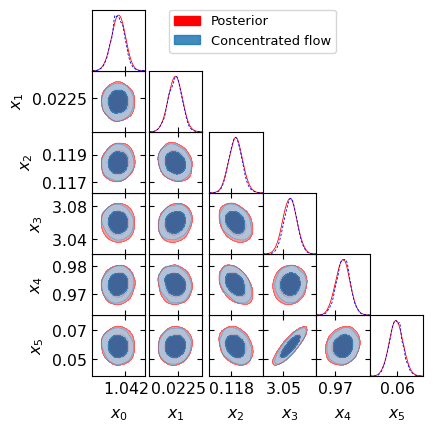

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 15/15 [00:38<00:00,  2.54s/it]


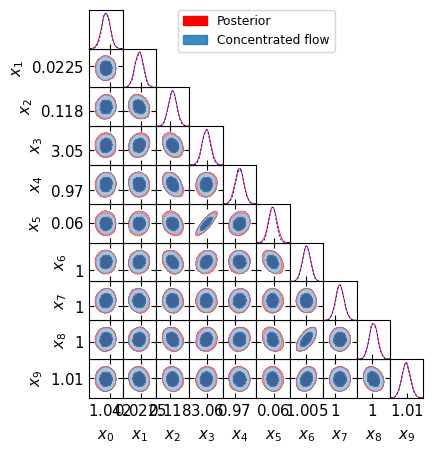

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 15/15 [01:03<00:00,  4.25s/it]


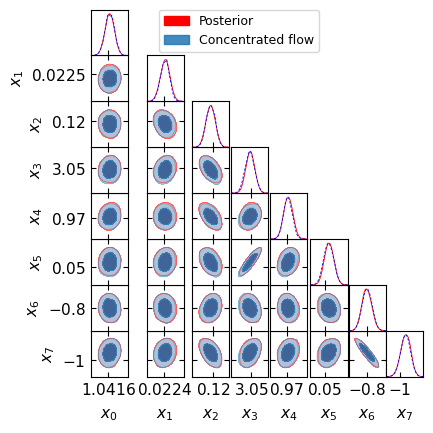

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 15/15 [01:20<00:00,  5.34s/it]


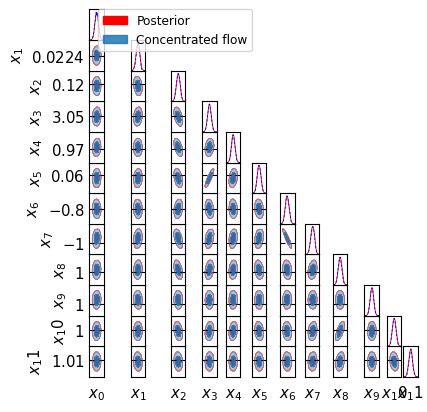

ensure that the concentrated flow is contained within the posterior


In [4]:
# training normalising flows for each object
lcdm_cosmo_only.train_model(verbose=True)
lcdm_full.train_model(verbose=True)
cpl_cosmo_only.train_model(verbose=True)
cpl_full.train_model(verbose=True)

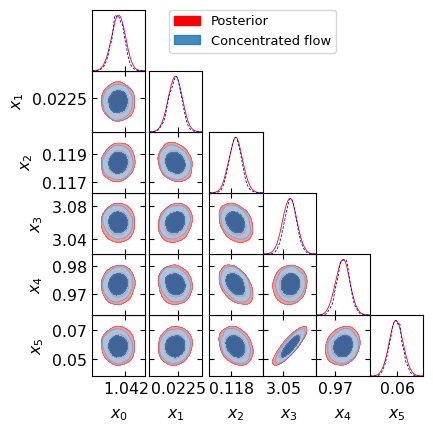

ensure that the concentrated flow is contained within the posterior


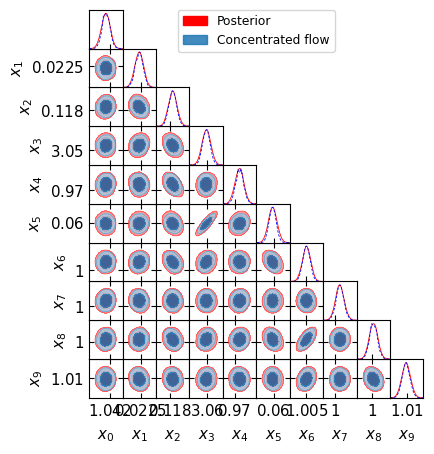

ensure that the concentrated flow is contained within the posterior


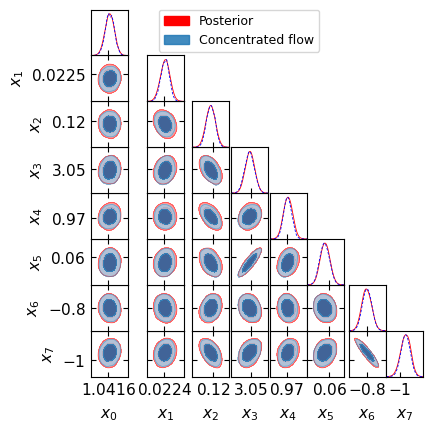

ensure that the concentrated flow is contained within the posterior


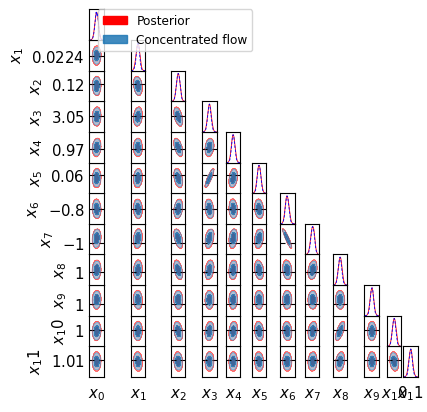

ensure that the concentrated flow is contained within the posterior


In [5]:
# adjusting the temperatures of the trained flows to ensure that the trained distribution is contained within the posterior. Default from above is $0.9$,

lcdm_cosmo_only.set_temp(temp=0.8, verbose=True)
lcdm_full.set_temp(temp=0.8, verbose=True)
cpl_cosmo_only.set_temp(temp=0.8, verbose=True)
cpl_full.set_temp(temp=0.8, verbose=True)

In [6]:
# MCEvidence evidence and Bayes factor

mce_cosmo_only = lcdm_cosmo_only.get_MCE_bayes_factor(cpl_cosmo_only)
mce_full = lcdm_full.get_MCE_bayes_factor(cpl_full)

RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.04952928869697333
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=6
INFO:MCEvidence.py.setup():162      Loading chain from ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE

ln(B)[k=1] = -1161.1502523026293


RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.9905857739394666
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=8
INFO:MCEvidence.py.setup():162      Loading chain from ../cpl_chains/ts_CMB-SPA+DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.1.txt
I

ln(B)[k=1] = -1161.798418456103


RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.00014339502693393462
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=10
INFO:MCEvidence.py.setup():162      Loading chain from ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/ts_CMB-SPA+DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/ts_CMB-SPA+DD+DES

ln(B)[k=1] = -1174.7405535494574


RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.002867900538678693
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=12
INFO:MCEvidence.py.setup():162      Loading chain from ../cpl_chains/ts_CMB-SPA+DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/ts_CMB-SPA+DD+DESI_BE.1.tx

ln(B)[k=1] = -1175.0168025346723




In [7]:
# harmonic evidence and Bayes factor

harm_cosmo_only = lcdm_cosmo_only.get_LMHE_bayes_factor(cpl_cosmo_only)
harm_full = lcdm_full.get_LMHE_bayes_factor(cpl_full)

In [8]:
# block_num variants for harmonic (CMB+BAO+SNe) — fully reinitialise and retrain

block_nums = [4, 12, 24]

# results at the original block_num=12 (already computed above)
harm_cosmo_only_blocks = {12: harm_cosmo_only}
harm_full_blocks = {12: harm_full}
hmZ_lcdm_cosmo = {12: lcdm_cosmo_only.get_hm_evidence()}
hmZ_cpl_cosmo = {12: cpl_cosmo_only.get_hm_evidence()}
hmZ_lcdm_full = {12: lcdm_full.get_hm_evidence()}
hmZ_cpl_full = {12: cpl_full.get_hm_evidence()}

lcdm_root = "../lcdm_chains/ts_CMB-SPA+DD+DESI"
cpl_root = "../cpl_chains/ts_CMB-SPA+DD+DESI"

for bn in [4, 24]:
    # cosmo-only
    a = make_and_train(lcdm_root, lcdm_cosmo_params, burnin=0.3, block_num=bn)
    b = make_and_train(cpl_root, cpl_cosmo_params, burnin=0.5, block_num=bn)
    harm_cosmo_only_blocks[bn] = a.get_LMHE_bayes_factor(b)
    hmZ_lcdm_cosmo[bn] = a.get_hm_evidence()
    hmZ_cpl_cosmo[bn] = b.get_hm_evidence()

    # cosmo + nuisance
    a = make_and_train(
        lcdm_root, lcdm_cosmo_params + nuisance_params, burnin=0.3, block_num=bn
    )
    b = make_and_train(
        cpl_root, cpl_cosmo_params + nuisance_params, burnin=0.5, block_num=bn
    )
    harm_full_blocks[bn] = a.get_LMHE_bayes_factor(b)
    hmZ_lcdm_full[bn] = a.get_hm_evidence()
    hmZ_cpl_full[bn] = b.get_hm_evidence()

<>:38: SyntaxWarning: invalid escape sequence '\L'
<>:53: SyntaxWarning: invalid escape sequence '\L'
<>:72: SyntaxWarning: invalid escape sequence '\L'
<>:38: SyntaxWarning: invalid escape sequence '\L'
<>:53: SyntaxWarning: invalid escape sequence '\L'
<>:72: SyntaxWarning: invalid escape sequence '\L'
/var/folders/xr/8_fm0nn90x74x5n0j96glblw0000gn/T/ipykernel_12832/3464579200.py:38: SyntaxWarning: invalid escape sequence '\L'
  -1155.6, color="black", linestyle=":", label="$\Lambda\mathrm{CDM}$: Nautilus"
/var/folders/xr/8_fm0nn90x74x5n0j96glblw0000gn/T/ipykernel_12832/3464579200.py:53: SyntaxWarning: invalid escape sequence '\L'
  label=f"$\Lambda\mathrm{{CDM}}$: LHME({bn})",
/var/folders/xr/8_fm0nn90x74x5n0j96glblw0000gn/T/ipykernel_12832/3464579200.py:72: SyntaxWarning: invalid escape sequence '\L'
  label="$\Lambda\mathrm{CDM}$: MCE",
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z fr

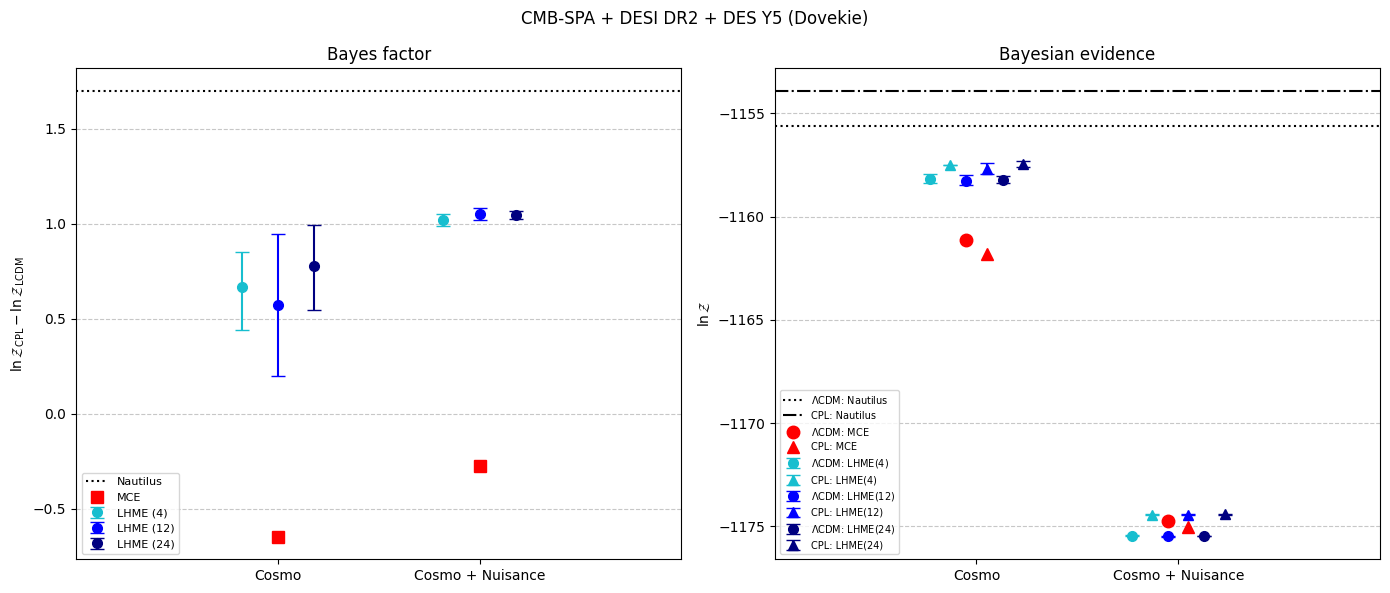

In [27]:
# plotting Bayes factor and individual evidences (CMB+BAO+SNe)
x_labels = ["Cosmo", "Cosmo + Nuisance"]
x_pos = np.array([0, 1])
block_offsets = {4: -0.18, 12: 0.0, 24: 0.18}
block_colors = {4: "tab:cyan", 12: "blue", 24: "navy"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Bayes factor ---
ax = axes[0]
ax.axhline(1.7, color="black", linestyle=":", label="Nautilus")
for bn in block_nums:
    means = [harm_cosmo_only_blocks[bn][0], harm_full_blocks[bn][0]]
    lower = [harm_cosmo_only_blocks[bn][1], harm_full_blocks[bn][1]]
    upper = [harm_cosmo_only_blocks[bn][2], harm_full_blocks[bn][2]]
    ax.errorbar(
        x_pos + block_offsets[bn],
        means,
        yerr=[lower, upper],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=f"LHME ({bn})",
        markersize=7,
    )
ax.plot(x_pos, [mce_cosmo_only, mce_full], "s", color="red", label="MCE", markersize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}_\mathrm{CPL}-\ln\mathcal{Z}_\mathrm{LCDM}$")
ax.set_title("Bayes factor")
ax.set_xlim(-1, 2)
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# --- Individual evidences ---
ax = axes[1]
ax.axhline(
    -1155.6, color="black", linestyle=":", label="$\Lambda\mathrm{CDM}$: Nautilus"
)
ax.axhline(-1153.9, color="black", linestyle="-.", label="CPL: Nautilus")
for bn in block_nums:
    lcdm_co = to_lnZ(hmZ_lcdm_cosmo[bn])
    cpl_co = to_lnZ(hmZ_cpl_cosmo[bn])
    lcdm_fu = to_lnZ(hmZ_lcdm_full[bn])
    cpl_fu = to_lnZ(hmZ_cpl_full[bn])
    ax.errorbar(
        x_pos + block_offsets[bn] - 0.05,
        [lcdm_co[0], lcdm_fu[0]],
        yerr=[[lcdm_co[1], lcdm_fu[1]], [lcdm_co[2], lcdm_fu[2]]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=f"$\Lambda\mathrm{{CDM}}$: LHME({bn})",
        markersize=7,
    )
    ax.errorbar(
        x_pos + block_offsets[bn] + 0.05,
        [cpl_co[0], cpl_fu[0]],
        yerr=[[cpl_co[1], cpl_fu[1]], [cpl_co[2], cpl_fu[2]]],
        fmt="^",
        color=block_colors[bn],
        capsize=5,
        label=f"CPL: LHME({bn})",
        markersize=7,
    )

ax.plot(
    x_pos - 0.05,
    [lcdm_cosmo_only.mcevidence, lcdm_full.mcevidence],
    "o",
    color="red",
    label="$\Lambda\mathrm{CDM}$: MCE",
    markersize=9,
)
ax.plot(
    x_pos + 0.05,
    [cpl_cosmo_only.mcevidence, cpl_full.mcevidence],
    "^",
    color="red",
    label="CPL: MCE",
    markersize=9,
)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}$")
ax.set_title("Bayesian evidence")
ax.set_xlim(-1, 2)
ax.legend(fontsize=7)
ax.grid(axis="y", linestyle="--", alpha=0.7)

fig.suptitle("CMB-SPA + DESI DR2 + DES Y5 (Dovekie)")
plt.tight_layout()
plt.show()

In [10]:
# including or excluding unconstrained parameters (BAO+SNe)

## parameters
lcdm_cosmo_params = [
    "H0",
    "omega_b",
    "omega_cdm",
]
prior_params = ["logA", "n_s"]
cpl_cosmo_params = lcdm_cosmo_params + ["w0_fld", "wa_fld"]

## initialising objects
lcdm_const_only = cosmo_model("../lcdm_chains/DD+DESI", block_num=12, burnin=0.5)
lcdm_all = cosmo_model("../lcdm_chains/DD+DESI", block_num=12, burnin=0.5)
cpl_const_only = cosmo_model("../cpl_chains/DD+DESI", block_num=12, burnin=0.5)
cpl_all = cosmo_model("../cpl_chains/DD+DESI", block_num=12, burnin=0.5)

## setting parameters
lcdm_const_only.set_sampled_params(lcdm_cosmo_params)
lcdm_all.set_sampled_params(lcdm_cosmo_params + prior_params)
cpl_const_only.set_sampled_params(cpl_cosmo_params)
cpl_all.set_sampled_params(cpl_cosmo_params + prior_params)

## check convergence on chains such so that correct burnin has been removed
print(f"LCDM R-1 = {lcdm_const_only.get_gelman_rubin()}")
print(f"CPL R-1 = {cpl_const_only.get_gelman_rubin()}")

LCDM R-1 = 0.009448838358317401
CPL R-1 = 0.004381148188664222


Training NF: 100%|██████████| 15/15 [00:16<00:00,  1.09s/it]


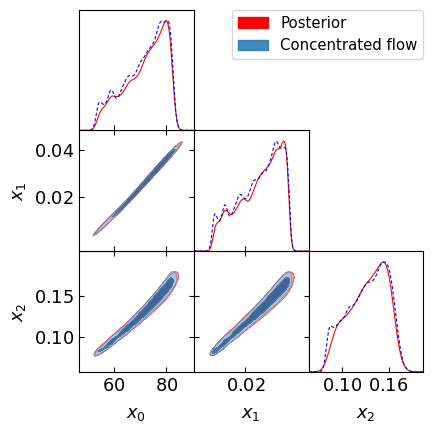

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 15/15 [00:18<00:00,  1.26s/it]


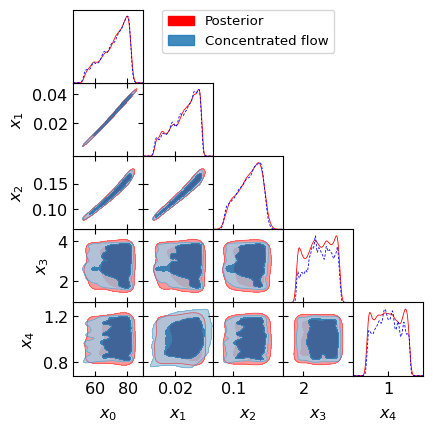

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 15/15 [02:14<00:00,  8.99s/it]


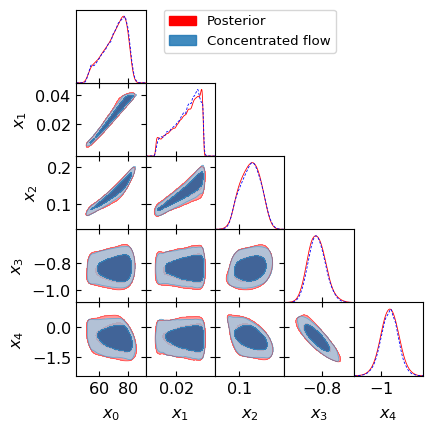

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 15/15 [02:48<00:00, 11.22s/it]


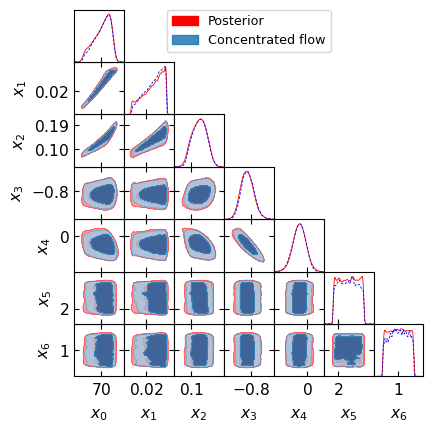

ensure that the concentrated flow is contained within the posterior


In [11]:
# training normalising flows for each BAO+SNe object
lcdm_const_only.train_model(verbose=True)
lcdm_all.train_model(verbose=True)
cpl_const_only.train_model(verbose=True)
cpl_all.train_model(verbose=True)

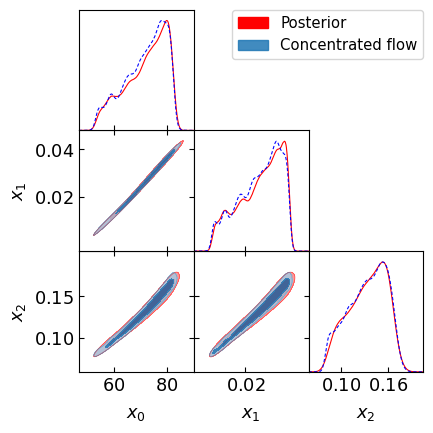

ensure that the concentrated flow is contained within the posterior


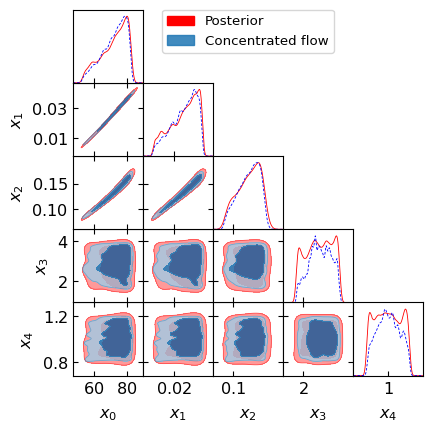

ensure that the concentrated flow is contained within the posterior


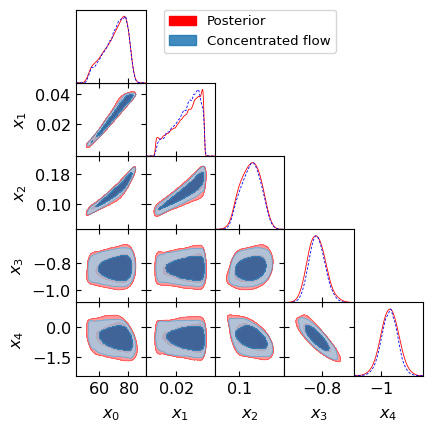

ensure that the concentrated flow is contained within the posterior


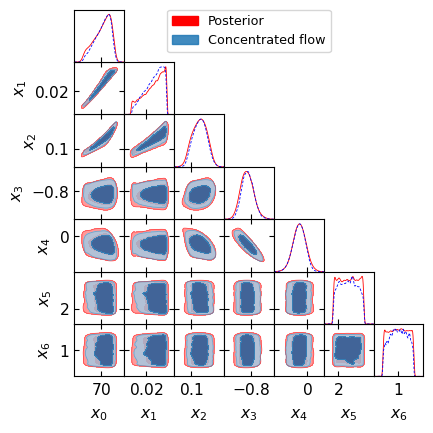

ensure that the concentrated flow is contained within the posterior


In [12]:
# adjust temperature of the trained flows for BAO+SNe
lcdm_const_only.set_temp(temp=0.8, verbose=True)
lcdm_all.set_temp(temp=0.7, verbose=True)
cpl_const_only.set_temp(temp=0.8, verbose=True)
cpl_all.set_temp(temp=0.8, verbose=True)

In [13]:
# MCEvidence evidence and Bayes factor (BAO+SNe)
mce_const_only = lcdm_const_only.get_MCE_bayes_factor(cpl_const_only)
mce_all = lcdm_all.get_MCE_bayes_factor(cpl_all)

RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../lcdm_chains/DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=5.6373
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=3
INFO:MCEvidence.py.setup():162      Loading chain from ../lcdm_chains/DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ../lcdm_chains/DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/DD+DESI_BE.1.txt
INFO:MCEvidence.py.removeBurn():423      Removing 1462 lines as burn in
INFO:MCEvid

ln(B)[k=1] = -831.8861135003057


RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../cpl_chains/DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=112.746
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=5
INFO:MCEvidence.py.setup():162      Loading chain from ../cpl_chains/DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ../cpl_chains/DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/DD+DESI_BE.1.txt
INFO:MCEvidence.py.removeBurn():423      Removing 9420 lines as burn in
INFO:MCEvidence.p

ln(B)[k=1] = -833.7488350759331


RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.read_list_to_array():633      loading: ../lcdm_chains/DD+DESI_BE.1.txt
INFO:MCEvidence.py.removeBurn():423      Removing 1462 lines as burn in
INFO:MCEvidence.py.removeBurn():423      Removing 1448 lines as burn in
INFO:MCEvidence.py.removeBurn():423      Removing 1440 lines as burn in
INFO:MCEvidence.py.removeBurn():423      Removing 1472 lines as burn in
INFO:MCEvidence.py.__init__():863      chain array dimensions: [13590] x 5 =
INFO:MCEvidence.py.get_covariance():948      Estimating covariance matrix using all chains
INFO:MCEvidence.py.get_covariance():952      covariance matrix estimated using nsample=13590
INFO:MCEvidence.py.get_samples():1005     getting samples for partition s1: nsamples=13590
INFO:MCEvidence.py.evidence():1322        ln(B)[k=1] = -832.0763449019956


ln(B)[k=1] = -832.0763449019956


RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../cpl_chains/DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=103.72631999999996
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=7
INFO:MCEvidence.py.setup():162      Loading chain from ../cpl_chains/DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ../cpl_chains/DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ../cpl_chains/DD+DESI_BE.1.txt
INFO:MCEvidence.py.removeBurn():423      Removing 9420 lines as burn in
INFO:M

ln(B)[k=1] = -833.9740305484951




In [14]:
# harmonic evidence and Bayes factor (BAO+SNe)
harm_const_only = lcdm_const_only.get_LMHE_bayes_factor(cpl_const_only)
harm_all = lcdm_all.get_LMHE_bayes_factor(cpl_all)

In [15]:
# block_num variants for harmonic (BAO+SNe) — fully reinitialise and retrain
harm_const_only_blocks = {12: harm_const_only}
harm_all_blocks = {12: harm_all}
hmZ_lcdm_const = {12: lcdm_const_only.get_hm_evidence()}
hmZ_cpl_const = {12: cpl_const_only.get_hm_evidence()}
hmZ_lcdm_all = {12: lcdm_all.get_hm_evidence()}
hmZ_cpl_all = {12: cpl_all.get_hm_evidence()}

lcdm_root_bs = "../lcdm_chains/DD+DESI"
cpl_root_bs = "../cpl_chains/DD+DESI"

for bn in [4, 24]:
    # constrained-only
    a = make_and_train(lcdm_root_bs, lcdm_cosmo_params, burnin=0.5, block_num=bn)
    b = make_and_train(cpl_root_bs, cpl_cosmo_params, burnin=0.5, block_num=bn)
    harm_const_only_blocks[bn] = a.get_LMHE_bayes_factor(b)
    hmZ_lcdm_const[bn] = a.get_hm_evidence()
    hmZ_cpl_const[bn] = b.get_hm_evidence()

    # constrained + prior-dominated
    a = make_and_train(
        lcdm_root_bs, lcdm_cosmo_params + prior_params, burnin=0.5, block_num=bn
    )
    b = make_and_train(
        cpl_root_bs, cpl_cosmo_params + prior_params, burnin=0.5, block_num=bn
    )
    harm_all_blocks[bn] = a.get_LMHE_bayes_factor(b)
    hmZ_lcdm_all[bn] = a.get_hm_evidence()
    hmZ_cpl_all[bn] = b.get_hm_evidence()

<>:42: SyntaxWarning: invalid escape sequence '\L'
<>:57: SyntaxWarning: invalid escape sequence '\L'
<>:76: SyntaxWarning: invalid escape sequence '\L'
<>:42: SyntaxWarning: invalid escape sequence '\L'
<>:57: SyntaxWarning: invalid escape sequence '\L'
<>:76: SyntaxWarning: invalid escape sequence '\L'
/var/folders/xr/8_fm0nn90x74x5n0j96glblw0000gn/T/ipykernel_12832/1314116609.py:42: SyntaxWarning: invalid escape sequence '\L'
  -833.2, color="black", linestyle=":", label="$\Lambda\mathrm{CDM}$: Nautilus"
/var/folders/xr/8_fm0nn90x74x5n0j96glblw0000gn/T/ipykernel_12832/1314116609.py:57: SyntaxWarning: invalid escape sequence '\L'
  label=f"$\Lambda\mathrm{{CDM}}$: LHME({bn})",
/var/folders/xr/8_fm0nn90x74x5n0j96glblw0000gn/T/ipykernel_12832/1314116609.py:76: SyntaxWarning: invalid escape sequence '\L'
  label="$\Lambda\mathrm{{CDM}}$: MCE",
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z f

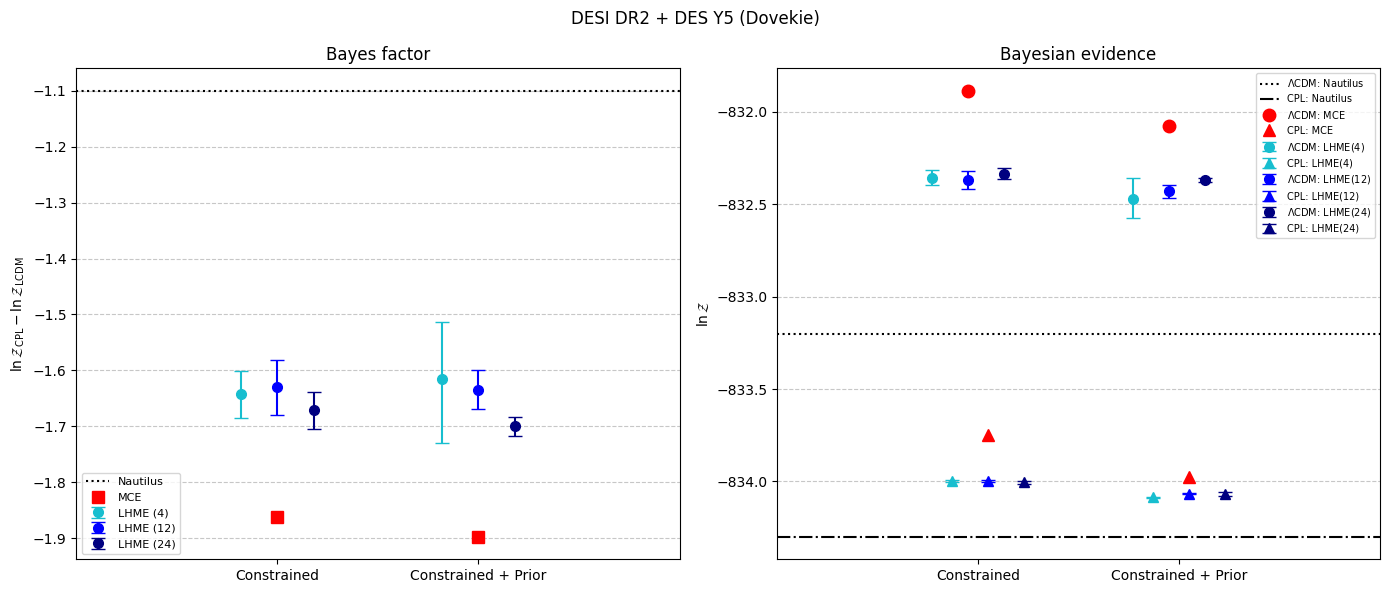

In [29]:
# plotting Bayes factor and individual evidences (BAO+SNe)
x_labels_bs = ["Constrained", "Constrained + Prior"]
x_pos_bs = np.array([0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

block_nums = [4, 12, 24]
block_offsets = {4: -0.18, 12: 0.0, 24: 0.18}
block_colors = {4: "tab:cyan", 12: "blue", 24: "navy"}
# --- Bayes factor ---
ax = axes[0]
ax.axhline(-1.1, color="black", linestyle=":", label="Nautilus")
ax.plot(
    x_pos_bs, [mce_const_only, mce_all], "s", color="red", label="MCE", markersize=9
)
for bn in block_nums:
    means = [harm_const_only_blocks[bn][0], harm_all_blocks[bn][0]]
    lower = [harm_const_only_blocks[bn][1], harm_all_blocks[bn][1]]
    upper = [harm_const_only_blocks[bn][2], harm_all_blocks[bn][2]]
    ax.errorbar(
        x_pos_bs + block_offsets[bn],
        means,
        yerr=[lower, upper],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=f"LHME ({bn})",
        markersize=7,
    )

ax.set_xticks(x_pos_bs)
ax.set_xticklabels(x_labels_bs)
ax.set_ylabel(r"$\ln\mathcal{Z}_\mathrm{CPL}-\ln\mathcal{Z}_\mathrm{LCDM}$")
ax.set_title("Bayes factor")
ax.set_xlim(-1, 2)
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# --- Individual evidences ---
ax = axes[1]
ax.axhline(
    -833.2, color="black", linestyle=":", label="$\Lambda\mathrm{CDM}$: Nautilus"
)
ax.axhline(-834.3, color="black", linestyle="-.", label="CPL: Nautilus")
for bn in block_nums:
    lcdm_co = to_lnZ(hmZ_lcdm_const[bn])
    cpl_co = to_lnZ(hmZ_cpl_const[bn])
    lcdm_al = to_lnZ(hmZ_lcdm_all[bn])
    cpl_al = to_lnZ(hmZ_cpl_all[bn])
    ax.errorbar(
        x_pos_bs + block_offsets[bn] - 0.05,
        [lcdm_co[0], lcdm_al[0]],
        yerr=[[lcdm_co[1], lcdm_al[1]], [lcdm_co[2], lcdm_al[2]]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=f"$\Lambda\mathrm{{CDM}}$: LHME({bn})",
        markersize=7,
    )
    ax.errorbar(
        x_pos_bs + block_offsets[bn] + 0.05,
        [cpl_co[0], cpl_al[0]],
        yerr=[[cpl_co[1], cpl_al[1]], [cpl_co[2], cpl_al[2]]],
        fmt="^",
        color=block_colors[bn],
        capsize=5,
        label=f"CPL: LHME({bn})",
        markersize=7,
    )

ax.plot(
    x_pos_bs - 0.05,
    [lcdm_const_only.mcevidence, lcdm_all.mcevidence],
    "o",
    color="red",
    label="$\Lambda\mathrm{{CDM}}$: MCE",
    markersize=9,
)
ax.plot(
    x_pos_bs + 0.05,
    [cpl_const_only.mcevidence, cpl_all.mcevidence],
    "^",
    color="red",
    label="CPL: MCE",
    markersize=9,
)
ax.set_xticks(x_pos_bs)
ax.set_xticklabels(x_labels_bs)
ax.set_ylabel(r"$\ln\mathcal{Z}$")
ax.set_title("Bayesian evidence")
ax.set_xlim(-1, 2)
ax.legend(fontsize=7)
ax.grid(axis="y", linestyle="--", alpha=0.7)

fig.suptitle("DESI DR2 + DES Y5 (Dovekie)")
plt.tight_layout()
plt.show()